#  Driver Inattention Detection
## [2026-1] Machine Learning Term Project

**데이터셋**: DMD (Driver Monitoring Dataset, Roboflow -> Kaggle에서 다운로드) — 14,856장, YOLO v3 (Keras) 형식

**모델**: HOG + LinearSVC (Baseline) · EfficientNet-B0 (native 224×224, 5.3M params) · ViT-Small
-> BaseLine인 서포트벡터머신과 SOTA 모델 EfficientNet-B0, Vit-small 모델을 비교하고자함. 강의시간에 들었던 ML 모델과 최근 모델을 비교해보며 이해도를 한층 더 높이는 게 목표

**평가지표**: Accuracy · Precision/Recall · F1 (macro/weighted) · ROC-AUC · **Risk-weighted Score**

| 클래스 | 위험도 |
|--------|--------|
| SafeDriving      | 🟢 Low |
| Yawn             | 🟡 Medium |
| Distracted       | 🟠 High |
| Drinking         | 🔴 Critical |
| SleepyDriving    | 🔴 Critical |
| DangerousDriving | 🔴 Critical |

---
### 주시해야할 점 -> 기존 설계사항과 변경한 주요 사항들
1. **데이터 로더 재작성**: ImageFolder 가정 → `_annotations.txt` 파싱 + **bbox 얼굴 크롭**
2. **클래스 불균형 처리**: `class_weight='balanced'` + `WeightedRandomSampler`
3. **Risk-weighted Score**: Critical 클래스를 Safe로 오분류할수록 큰 비용 부여


---
## 0. 환경 설정

In [1]:
import sys
import torch
print(f'Python  : {sys.version.split()[0]}')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU memory: {mem_gb:.1f} GB')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice  : {device}')

Python  : 3.12.13
PyTorch : 2.10.0+cu128
CUDA available: True
GPU : Tesla T4
GPU memory: 15.6 GB

Device  : cuda


In [2]:
# ── 추가 패키지 설치 (timm, scikit-image) ──
import subprocess, sys
for pkg, mod in [('timm','timm'), ('scikit-image','skimage')]:
    try:
        __import__(mod)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

# ── 공통 import ──
import os, time, random, warnings, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from collections import Counter

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import timm

from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)

warnings.filterwarnings('ignore')
# 시드를 고정하여 실험환경을 고정 -> 일관된 성능 및 지표 비교
SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()
print('✓ Libraries loaded   | timm:', timm.__version__)

✓ Libraries loaded   | timm: 1.0.26


In [ ]:
# ── 한글 폰트 (Colab/Linux) ──
import subprocess
subprocess.run(['apt', '-qq', 'install', '-y', 'fonts-nanum'], check=False, capture_output=True)
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)
print('✓ 한글 폰트 준비')

✓ 한글 폰트 준비


---
## 1. Google Drive 마운트 & 경로

> 데이터셋이 Drive에 있는 경우 사용합니다. 경로에 맞게 `DATASET_PATH`를 수정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── 본인 Drive 내 데이터셋 경로로 수정 ──
DATASET_PATH = '/content/drive/MyDrive/Machine_Learning_Term_Project/Driver_inattention_data'

print(f'경로: {DATASET_PATH}')
print(f'존재 여부: {os.path.exists(DATASET_PATH)}')
if os.path.exists(DATASET_PATH):
    print('하위 폴더/파일:', sorted(os.listdir(DATASET_PATH))[:10])

Mounted at /content/drive
경로: /content/drive/MyDrive/Machine_Learning_Term_Project/Driver_inattention_data
존재 여부: True
하위 폴더/파일: ['.DS_Store', 'README.dataset.txt', 'README.roboflow.txt', 'test', 'train', 'valid']


In [ ]:
# ── Drive → Colab 로컬 복사 (I/O 가속) ──
# Drive에서 zip 파일 1개만 복사 후 압축 해제 (훨씬 빠름)
import shutil, os

DATASET_PATH = '/content/drive/MyDrive/Machine_Learning_Term_Project/Driver_inattention_data'
LOCAL_BASE = '/content/dmd'

if not os.path.exists(LOCAL_BASE):
    print('Drive → 로컬 복사 중... (~5-10분)')
    shutil.copytree(DATASET_PATH, LOCAL_BASE)
    print('✓ 복사 완료')
else:
    print('✓ 이미 존재')

BASE = DATASET_PATH
TRAIN_DIR = os.path.join(BASE, 'train')
VAL_DIR   = os.path.join(BASE, 'valid')
TEST_DIR  = os.path.join(BASE, 'test')

print()
for split, d in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    n_imgs = len([f for f in os.listdir(d) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    has_ann = os.path.exists(os.path.join(d, '_annotations.txt'))
    print(f'  {split:<5}: {n_imgs:>6}장 | _annotations.txt {"✓" if has_ann else "✗"}')

Drive → 로컬 복사 중... (~5-10분)
✓ 복사 완료

  Train:  11952장 | _annotations.txt ✓
  Val  :   1922장 | _annotations.txt ✓
  Test :    985장 | _annotations.txt ✓


---
## 2. 데이터 파싱

`_annotations.txt`의 각 줄은 `filename x1,y1,x2,y2,class_idx` 형식.
`_classes.txt`의 줄 순서가 곧 class index.

In [ ]:
def parse_annotations(ann_path, img_dir):
    """Roboflow가 export한 _annotations.txt (YOLO v3 스타일 텍스트)에서
    (이미지경로, bbox, class) 추출.
    한 줄: 'filename.jpg x1,y1,x2,y2,cls'
    bbox는 분류 모델 입력 전 '얼굴 영역 크롭'에만 사용 — YOLO 모델은 학습하지 않음.
    """
    rows = []
    with open(ann_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            parts = line.split(' ')
            if len(parts) < 2: continue
            fname = parts[0]
            box = parts[1].split(',')
            x1, y1, x2, y2, cls = (int(v) for v in box[:5])
            rows.append({
                'path': os.path.join(img_dir, fname),
                'x1':x1,'y1':y1,'x2':x2,'y2':y2,
                'label': cls,
            })
    return pd.DataFrame(rows)

# ── 클래스 목록 ──
with open(os.path.join(TRAIN_DIR, '_classes.txt')) as f:
    CLASS_LIST = [c.strip() for c in f.readlines() if c.strip()]
NUM_CLASSES = len(CLASS_LIST)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_LIST)}
print(f'클래스 ({NUM_CLASSES}개): {CLASS_LIST}')

# ── 3-split 파싱 ──
df_train = parse_annotations(os.path.join(TRAIN_DIR, '_annotations.txt'), TRAIN_DIR)
df_val   = parse_annotations(os.path.join(VAL_DIR,   '_annotations.txt'), VAL_DIR)
df_test  = parse_annotations(os.path.join(TEST_DIR,  '_annotations.txt'), TEST_DIR)
for df in [df_train, df_val, df_test]:
    df['class_name'] = df['label'].map(lambda i: CLASS_LIST[i])

print(f'\nTrain: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')
df_train.head()

클래스 (6개): ['DangerousDriving', 'Distracted', 'Drinking', 'SafeDriving', 'SleepyDriving', 'Yawn']

Train: 11948 | Val: 1922 | Test: 985


,path,x1,y1,x2,y2,label,class_name
0,/content/drive/MyDrive/Machine_Learning_Term_P...,212,126,321,261,3,SafeDriving
1,/content/drive/MyDrive/Machine_Learning_Term_P...,127,113,255,301,3,SafeDriving
2,/content/drive/MyDrive/Machine_Learning_Term_P...,308,122,485,360,2,Drinking
3,/content/drive/MyDrive/Machine_Learning_Term_P...,338,108,525,315,0,DangerousDriving
4,/content/drive/MyDrive/Machine_Learning_Term_P...,216,116,352,273,3,SafeDriving


In [ ]:
# ── 위험도 매핑 (도메인 지식) ──
RISK_LEVEL = {
    'SafeDriving':      ('Low',      '#2ecc71'),
    'Yawn':             ('Medium',   '#f39c12'),
    'Distracted':       ('High',     '#e67e22'),
    'Drinking':         ('Critical', '#e74c3c'),
    'SleepyDriving':    ('Critical', '#c0392b'),
    'DangerousDriving': ('Critical', '#8b0000'),
}
RISK_W = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}

def get_risk(cls_name):
    return RISK_LEVEL.get(cls_name, ('Medium', '#f39c12'))

print('클래스별 위험도:')
for c in CLASS_LIST:
    risk, _ = get_risk(c)
    print(f'  {c:<18}  →  {risk}')

클래스별 위험도:
  DangerousDriving    →  Critical
  Distracted          →  High
  Drinking            →  Critical
  SafeDriving         →  Low
  SleepyDriving       →  Critical
  Yawn                →  Medium


---
## 3. EDA

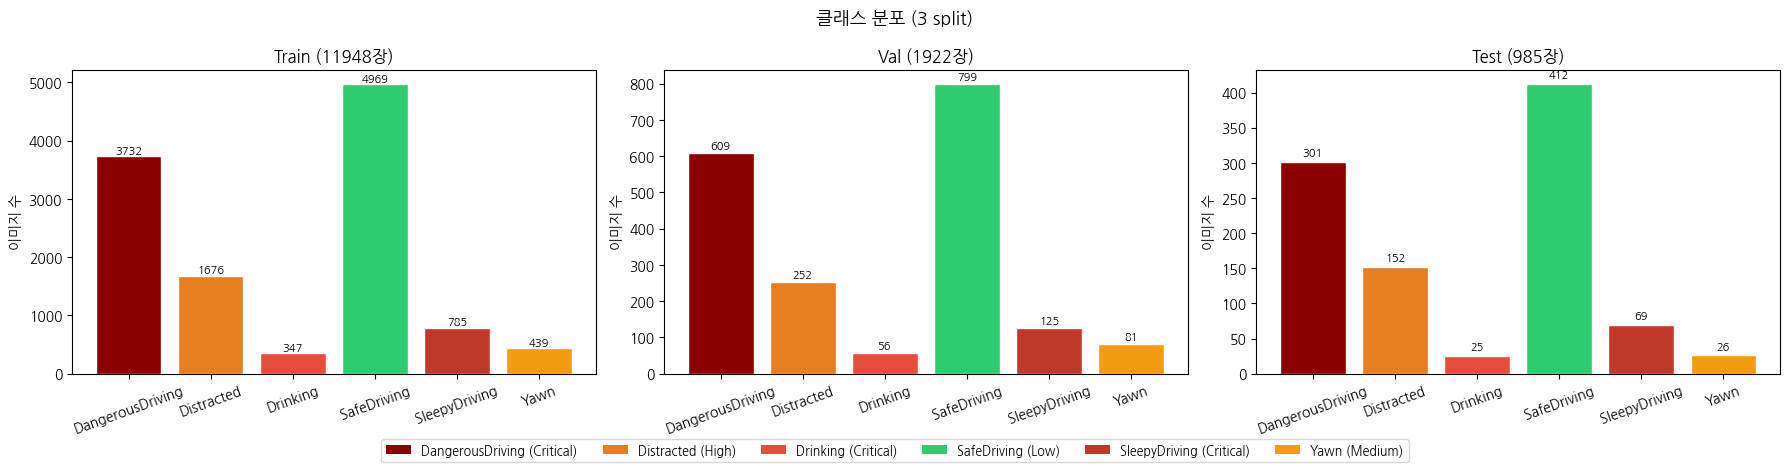


Train 불균형 (max/min): 14.32
{'SafeDriving': 4969, 'DangerousDriving': 3732, 'Distracted': 1676, 'SleepyDriving': 785, 'Yawn': 439, 'Drinking': 347}


In [ ]:
# ── 클래스 분포 (Train/Val/Test) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

for ax, (name, df) in zip(axes, [('Train', df_train), ('Val', df_val), ('Test', df_test)]):
    counts = [(df['class_name']==c).sum() for c in CLASS_LIST]
    colors = [get_risk(c)[1] for c in CLASS_LIST]
    bars = ax.bar(CLASS_LIST, counts, color=colors, edgecolor='white')

    for b, cnt in zip(bars, counts):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+5,
                str(cnt), ha='center', va='bottom', fontsize=8)

    ax.set_title(f'{name} ({len(df)}장)', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.set_ylabel('이미지 수')

legend_els = [mpatches.Patch(facecolor=RISK_LEVEL[k][1], label=f'{k} ({RISK_LEVEL[k][0]})')
              for k in CLASS_LIST]

fig.legend(handles=legend_els, loc='lower center', ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.04))
plt.suptitle('클래스 분포 (3 split)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

train_counts = df_train['class_name'].value_counts()
print(f'\nTrain 불균형 (max/min): {train_counts.max() / train_counts.min():.2f}')
print(train_counts.to_dict())

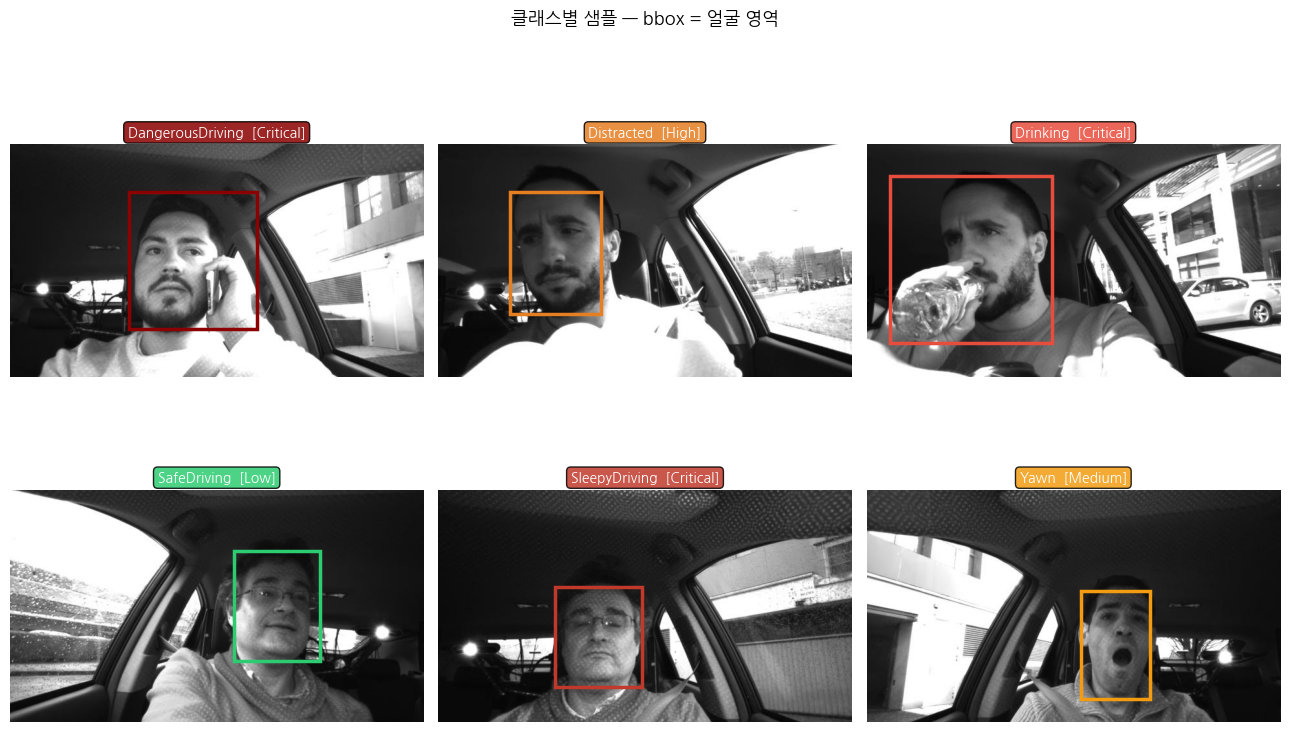

In [ ]:
# ── 클래스별 샘플 (bbox 그려서) ──
fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
axes = axes.flatten()
for i, cls in enumerate(CLASS_LIST):
    sub = df_train[df_train['class_name'] == cls]
    if len(sub) == 0: continue
    row = sub.sample(1, random_state=SEED).iloc[0]
    img = Image.open(row['path']).convert('RGB')
    axes[i].imshow(img)
    rect = mpatches.Rectangle(
        (row['x1'], row['y1']), row['x2']-row['x1'], row['y2']-row['y1'],
        linewidth=2.5, edgecolor=get_risk(cls)[1], facecolor='none'
    )
    axes[i].add_patch(rect)
    risk, color = get_risk(cls)
    axes[i].set_title(f'{cls}  [{risk}]', fontsize=10, color='white',
                      bbox=dict(boxstyle='round', facecolor=color, alpha=0.85))
    axes[i].axis('off')
plt.suptitle('클래스별 샘플 — bbox = 얼굴 영역', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_samples.png', dpi=130, bbox_inches='tight')
plt.show()

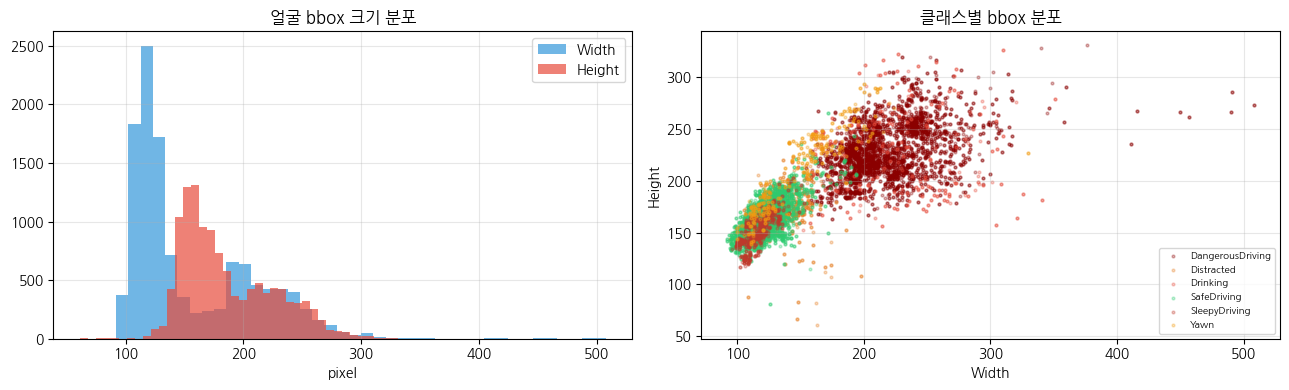

평균 얼굴 크기: 156 × 186 px


In [ ]:
# ── bbox 크기 통계 ──
df_train['bbox_w'] = df_train['x2'] - df_train['x1']
df_train['bbox_h'] = df_train['y2'] - df_train['y1']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_train['bbox_w'], bins=40, alpha=0.7, label='Width',  color='#3498db')
axes[0].hist(df_train['bbox_h'], bins=40, alpha=0.7, label='Height', color='#e74c3c')
axes[0].set_xlabel('pixel'); axes[0].set_title('얼굴 bbox 크기 분포')
axes[0].legend(); axes[0].grid(alpha=0.3)

for c in CLASS_LIST:
    sub = df_train[df_train['class_name']==c]
    axes[1].scatter(sub['bbox_w'], sub['bbox_h'], s=4, alpha=0.3,
                    label=c, color=get_risk(c)[1])
axes[1].set_xlabel('Width'); axes[1].set_ylabel('Height')
axes[1].set_title('클래스별 bbox 분포')
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('eda_bbox_stats.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'평균 얼굴 크기: {df_train.bbox_w.mean():.0f} × {df_train.bbox_h.mean():.0f} px')

---
## 4. Dataset & 전처리

**핵심 전처리**
1. bbox로 얼굴 영역 **크롭** → 배경 잡음 제거
2. 20% 패딩으로 여백 확보 (Drinking/DangerousDriving 행동 단서 포함)
3. 224×224 리사이즈 (사전학습 모델 입력)
4. 1ch grayscale → 3ch 복제 (RGB 사전학습 가중치 활용)
5. Train만 augmentation (flip/rotate/affine/jitter/erase)

In [ ]:
class DMDDataset(Dataset):
    """bbox 얼굴 크롭 → transform 적용"""
    def __init__(self, df, transform=None, pad_ratio=0.2):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.pad_ratio = pad_ratio

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        img = Image.open(r['path']).convert('RGB')
        W, H = img.size
        bw = r['x2'] - r['x1']; bh = r['y2'] - r['y1']
        px = int(bw * self.pad_ratio); py = int(bh * self.pad_ratio)
        x1 = max(0, r['x1']-px); y1 = max(0, r['y1']-py)
        x2 = min(W, r['x2']+px); y2 = min(H, r['y2']+py)
        img = img.crop((x1, y1, x2, y2))
        if self.transform:
            img = self.transform(img)
        return img, int(r['label'])

IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.1)),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

train_ds = DMDDataset(df_train, transform=train_tf)
val_ds   = DMDDataset(df_val,   transform=eval_tf)
test_ds  = DMDDataset(df_test,  transform=eval_tf)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Train: 11948 | Val: 1922 | Test: 985


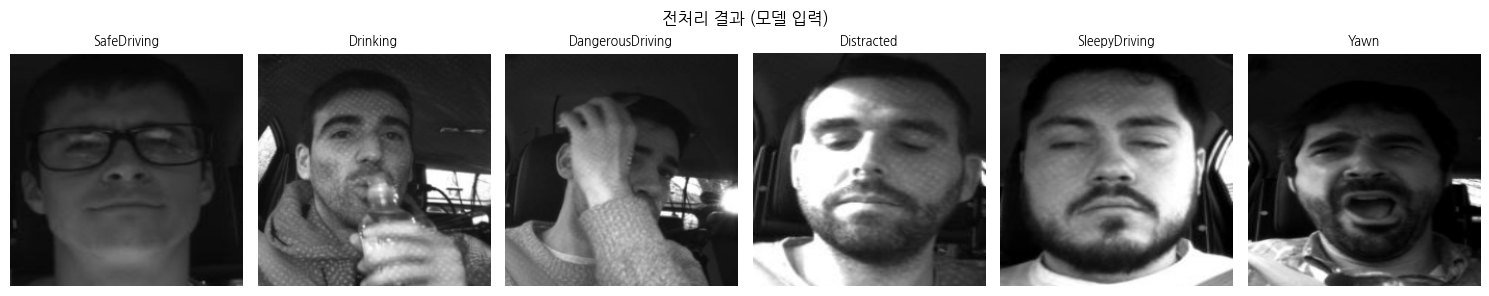

In [ ]:
# ── 크롭/리사이즈 결과 미리보기 (모델 입력 그대로) ──
preview_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
])
preview_ds = DMDDataset(df_train, transform=preview_tf)
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(15, 3))
shown = set(); i = 0
for ax in axes:
    while i < len(df_train):
        if df_train.iloc[i]['label'] not in shown:
            shown.add(df_train.iloc[i]['label'])
            img, lbl = preview_ds[i]
            ax.imshow(img); ax.set_title(CLASS_LIST[lbl], fontsize=9); ax.axis('off')
            i += 1; break
        i += 1
plt.suptitle('전처리 결과 (모델 입력)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_crops.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# ── 클래스 불균형 처리: class weights + WeightedRandomSampler ──
labels_arr = df_train['label'].values

class_weights = compute_class_weight('balanced',
                                      classes=np.arange(NUM_CLASSES),
                                      y=labels_arr)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)
print('Class weights (for CrossEntropyLoss):')
for i, c in enumerate(CLASS_LIST):
    print(f'  {c:<18} weight={class_weights[i]:.3f}')

sample_w = np.array([class_weights[l] for l in labels_arr])
sampler  = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f'\n배치 사이즈: {BATCH_SIZE}')

Class weights (for CrossEntropyLoss):
  DangerousDriving   weight=0.534
  Distracted         weight=1.188
  Drinking           weight=5.739
  SafeDriving        weight=0.401
  SleepyDriving      weight=2.537
  Yawn               weight=4.536

배치 사이즈: 32


---
## 5. Baseline — HOG + LinearSVC

수업에서 다룬 classical ML 베이스라인.
- **HOG** (Histogram of Oriented Gradients, Dalal & Triggs 2005): 그래디언트 방향 히스토그램
- **LinearSVC**: 10k+ 샘플에서도 빠르게 수렴. (RBF SVM은 데이터 규모에 비해 너무 느려 제외)
- `class_weight='balanced'`로 불균형 처리
- Val set으로 C (정규화 강도) 튜닝

In [ ]:
# ── HOG 피처 추출 ──
HOG_SIZE = 64
HOG_PARAMS = dict(orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2),
                  block_norm='L2-Hys', feature_vector=True)

def extract_hog(df, size=HOG_SIZE, pad_ratio=0.2, desc='HOG'):
    feats, lbls = [], []
    t0 = time.time()
    for i, r in enumerate(df.itertuples()):
        img = Image.open(r.path).convert('L')
        W, H = img.size
        bw = r.x2 - r.x1; bh = r.y2 - r.y1
        px = int(bw*pad_ratio); py = int(bh*pad_ratio)
        x1 = max(0, r.x1-px); y1 = max(0, r.y1-py)
        x2 = min(W, r.x2+px); y2 = min(H, r.y2+py)
        img = img.crop((x1,y1,x2,y2)).resize((size, size), Image.BILINEAR)
        feats.append(hog(np.array(img), **HOG_PARAMS))
        lbls.append(r.label)
        if (i+1) % 2000 == 0:
            print(f'  [{desc}] {i+1}/{len(df)}  ({time.time()-t0:.1f}s)')
    print(f'  [{desc}] 완료 {len(df)}장 — {time.time()-t0:.1f}s, dim={len(feats[0])}')
    return np.array(feats, dtype=np.float32), np.array(lbls)

print('HOG 피처 추출 중...')
X_train_hog, y_train_hog = extract_hog(df_train, desc='Train')
X_val_hog,   y_val_hog   = extract_hog(df_val,   desc='Val')
X_test_hog,  y_test_hog  = extract_hog(df_test,  desc='Test')
print(f'\nShape — Train {X_train_hog.shape} | Val {X_val_hog.shape} | Test {X_test_hog.shape}')

HOG 피처 추출 중...
  [Train] 2000/11948  (448.4s)
  [Train] 4000/11948  (884.8s)
  [Train] 6000/11948  (1312.3s)
  [Train] 8000/11948  (1757.4s)
  [Train] 10000/11948  (2205.8s)
  [Train] 완료 11948장 — 2645.4s, dim=1764
  [Val] 완료 1922장 — 1279.9s, dim=1764
  [Test] 완료 985장 — 663.9s, dim=1764

Shape — Train (11948, 1764) | Val (1922, 1764) | Test (985, 1764)


In [ ]:
import numpy as np

np.savez('/content/drive/MyDrive/Machine_Learning_Term_Project/hog_features.npz',
         X_train=X_train_hog, y_train=y_train_hog,
         X_val=X_val_hog,     y_val=y_val_hog,
         X_test=X_test_hog,   y_test=y_test_hog)
print('HOG 피처 저장 완료')

HOG 피처 저장 완료


In [ ]:
data = np.load('/content/drive/MyDrive/Machine_Learning_Term_Project/hog_features.npz')
X_train, y_train = data['X_train'], data['y_train']
X_val,   y_val   = data['X_val'],   data['y_val']
X_test,  y_test  = data['X_test'],  data['y_test']
print('HOG 피처 로드 완료')

HOG 피처 로드 완료


In [ ]:
# ── LinearSVC: C 튜닝 (val set) ──
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

C_grid = [0.01, 0.1, 1.0, 10.0]
best_C, best_val_acc, best_svm = None, 0, None
print(f'{"C":>8} {"Train Acc":>12} {"Val Acc":>10}')
print('-'*32)
for C in C_grid:
    svm = LinearSVC(C=C, class_weight='balanced', max_iter=3000, dual='auto', random_state=SEED)
    svm.fit(X_train_s, y_train)
    tr = svm.score(X_train_s, y_train)
    vl = svm.score(X_val_s,   y_val)
    print(f'{C:>8.2f} {tr:>12.4f} {vl:>10.4f}')
    if vl > best_val_acc:
        best_val_acc, best_C, best_svm = vl, C, svm
print(f'\n→ Best C={best_C}  Val Acc={best_val_acc:.4f}')

       C    Train Acc    Val Acc
--------------------------------
    0.01       0.9705     0.9121
    0.10       0.9921     0.9011
    1.00       0.9980     0.8897
   10.00       0.9997     0.8647

→ Best C=0.01  Val Acc=0.9121


In [ ]:
# ── HOG+SVM Test 평가 ──
svm_preds = best_svm.predict(X_test_s)
# LinearSVC.decision_function → OvR 점수 → softmax 정규화로 의사-확률 생성
svm_scores = best_svm.decision_function(X_test_s)
svm_probs = np.exp(svm_scores - svm_scores.max(axis=1, keepdims=True))
svm_probs /= svm_probs.sum(axis=1, keepdims=True)

svm_acc  = accuracy_score(y_test, svm_preds)
svm_f1m  = f1_score(y_test, svm_preds, average='macro')
svm_f1w  = f1_score(y_test, svm_preds, average='weighted')
svm_prec = precision_score(y_test, svm_preds, average='macro', zero_division=0)
svm_rec  = recall_score(y_test, svm_preds, average='macro', zero_division=0)
svm_auc  = roc_auc_score(y_test, svm_probs, multi_class='ovr', average='macro')

print(f'[HOG+SVM 최종 Test]')
print(f'  Accuracy           : {svm_acc:.4f}')
print(f'  Precision (macro)  : {svm_prec:.4f}')
print(f'  Recall    (macro)  : {svm_rec:.4f}')
print(f'  F1 (macro/weighted): {svm_f1m:.4f} / {svm_f1w:.4f}')
print(f'  ROC-AUC (OvR macro): {svm_auc:.4f}')
print('\n--- 분류 리포트 ---')
print(classification_report(y_test, svm_preds, target_names=CLASS_LIST, zero_division=0))

[HOG+SVM 최종 Test]
  Accuracy           : 0.9117
  Precision (macro)  : 0.8555
  Recall    (macro)  : 0.8858
  F1 (macro/weighted): 0.8690 / 0.9122
  ROC-AUC (OvR macro): 0.9814

--- 분류 리포트 ---
                  precision    recall  f1-score   support

DangerousDriving       0.98      0.99      0.99       301
      Distracted       0.86      0.86      0.86       152
        Drinking       0.83      0.80      0.82        25
     SafeDriving       0.93      0.89      0.91       412
   SleepyDriving       0.73      0.81      0.77        69
            Yawn       0.81      0.96      0.88        26

        accuracy                           0.91       985
       macro avg       0.86      0.89      0.87       985
    weighted avg       0.91      0.91      0.91       985



In [ ]:
# ── ① SVM 저장 ──
import joblib
import numpy as np

# 세션 재시작으로 날아간 변수 재정의
HOG_SIZE = 64
HOG_PARAMS = dict(orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2),
                  block_norm='L2-Hys', feature_vector=True)

SAVE_DIR = '/content/drive/MyDrive/Machine_Learning_Term_Project/results'
os.makedirs(SAVE_DIR, exist_ok=True)
joblib.dump({'svm': best_svm, 'scaler': scaler, 'best_C': best_C,
             'hog_params': HOG_PARAMS, 'hog_size': HOG_SIZE},
            os.path.join(SAVE_DIR, 'hog_svm.joblib'))
np.savez(os.path.join(SAVE_DIR, '_svm_results.npz'),
         preds=svm_preds, probs=svm_probs, labels=y_test)

# 메타 & df_test도 같이 (다음 단계 안전망)
import json
with open(os.path.join(SAVE_DIR, 'meta.json'), 'w') as f:
    json.dump({'class_list': CLASS_LIST, 'class_to_idx': CLASS_TO_IDX,
               'risk_level': {k: list(v) for k,v in RISK_LEVEL.items()},
               'risk_w': RISK_W, 'img_size': IMG_SIZE, 'batch_size': BATCH_SIZE,
               'hog_params': HOG_PARAMS, 'hog_size': HOG_SIZE, 'best_svm_C': best_C,
               'splits': {'train': len(df_train), 'val': len(df_val), 'test': len(df_test)},
              }, f, indent=2, ensure_ascii=False)
df_test.to_parquet(os.path.join(SAVE_DIR, 'df_test.parquet'), index=False)
df_train.to_parquet(os.path.join(SAVE_DIR, 'df_train.parquet'), index=False)
print('SVM + 메타 + df 저장 완료')

SVM + 메타 + df 저장 완료


---
## 6. 딥러닝 공용 함수

In [ ]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    tot_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        tot_loss += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
    return tot_loss/total, correct/total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    tot_loss = correct = total = 0
    preds_a, labels_a, probs_a = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        loss = criterion(out, labels)
        probs = F.softmax(out, dim=1)
        tot_loss += loss.item() * imgs.size(0)
        preds = out.argmax(1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        preds_a.extend(preds.cpu().numpy())
        labels_a.extend(labels.cpu().numpy())
        probs_a.append(probs.cpu().numpy())
    return (tot_loss/total, correct/total,
            np.array(preds_a), np.array(labels_a), np.concatenate(probs_a))

def train_model(model, tr_loader, vl_loader, epochs, lr, name='model',
                weight_decay=1e-3, class_weight_tensor=None,
                label_smoothing=0.1, patience=5, eta_min=1e-6):

    criterion = nn.CrossEntropyLoss(weight=class_weight_tensor,
                                     label_smoothing=label_smoothing)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=eta_min)

    history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc']}
    best_val_loss = float('inf')
    best_path = f'{name}_best.pth'
    counter = 0  # early stop counter

    for ep in range(1, epochs+1):
        t0 = time.time()
        tl, ta = train_epoch(model, tr_loader, criterion, optimizer)
        vl, va, _, _, _ = eval_epoch(model, vl_loader, criterion)
        scheduler.step()
        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['train_acc'].append(ta);  history['val_acc'].append(va)

        flag = ''
        if vl < best_val_loss:
            best_val_loss = vl
            torch.save(model.state_dict(), best_path)
            counter = 0
            flag = '✓ BEST'
        else:
            counter += 1
            if counter >= patience:
                flag = f'⏹ Early stop (patience {patience} reached)'

        cur_lr = scheduler.get_last_lr()[0]
        print(f'  Ep [{ep:02d}/{epochs}]  Tr L:{tl:.4f} Acc:{ta:.4f} | '
              f'Vl L:{vl:.4f} Acc:{va:.4f} | LR:{cur_lr:.2e}  ({time.time()-t0:.1f}s) {flag}')

        if counter >= patience: break

    print(f'\n  best Val Loss: {best_val_loss:.4f}')
    model.load_state_dict(torch.load(best_path))
    return model, history

def merge_histories(*hists):
    return {k: sum([h[k] for h in hists], []) for k in hists[0].keys()}

def plot_curves(history, phase_split=None, title='Training Curves', save=None):
    eps = range(1, len(history['train_loss'])+1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, ktr, kvl, ylabel in [(axes[0],'train_loss','val_loss','Loss'),
                                  (axes[1],'train_acc', 'val_acc', 'Accuracy')]:
        ax.plot(eps, history[ktr], 'b-o', ms=3, label='Train')
        ax.plot(eps, history[kvl], 'r-o', ms=3, label='Val')
        if phase_split:
            ax.axvline(phase_split+0.5, ls='--', color='gray', alpha=0.6, label='Phase 1→2')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle(title, fontweight='bold')
    plt.tight_layout()
    if save: plt.savefig(save, dpi=130, bbox_inches='tight')
    plt.show()

print('✓ 학습 함수 정의 완료 (Early Stopping + Label Smoothing 포함)')

✓ 학습 함수 정의 완료 (Early Stopping + Label Smoothing 포함)


---
## 7. Model A — EfficientNet-B0 (2-Phase)

| Phase | 학습 대상 | LR | Epochs |
|-------|-----------|-----|--------|
| 1 | Classifier head | 1e-3 | 3 |
| 2 | 전체 fine-tune  | 1e-4 | 7 |

In [ ]:
def build_efficientnet(num_classes, freeze=True):
    m = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    if freeze:
        for p in m.parameters(): p.requires_grad = False
    in_f = m.classifier[1].in_features  # 1280
    m.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_f, 256), nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes),
    )
    return m.to(device)

set_seed()
effnet = build_efficientnet(NUM_CLASSES, freeze=True)
n_tr = sum(p.numel() for p in effnet.parameters() if p.requires_grad)
n_all = sum(p.numel() for p in effnet.parameters())
print(f'EfficientNet-B0 — total: {n_all:,}, trainable: {n_tr:,} ({n_tr/n_all*100:.1f}%)')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 83.9MB/s]


EfficientNet-B0 — total: 4,337,026, trainable: 329,478 (7.6%)


In [ ]:
# Phase 1
print('='*60, '\n  Phase 1 — Head only  (lr=1e-3, 3 epochs warmup)\n', '='*60)
effnet, hist_eff_p1 = train_model(
    effnet, train_loader, val_loader, epochs=3, lr=1e-3,
    name='eff_p1', class_weight_tensor=class_weights_t,
    patience=99,  # warmup 단계라 early stop 비활성화
)

  Phase 1 — Head only  (lr=1e-3, 3 epochs warmup)
  Ep [01/3]  Tr L:0.7472 Acc:0.6142 | Vl L:1.3714 Acc:0.4615 | LR:7.50e-04  (108.8s) ✓ BEST
  Ep [02/3]  Tr L:0.6123 Acc:0.7248 | Vl L:1.2497 Acc:0.5578 | LR:2.51e-04  (104.8s) ✓ BEST
  Ep [03/3]  Tr L:0.5812 Acc:0.7500 | Vl L:1.2193 Acc:0.5806 | LR:1.00e-06  (105.5s) ✓ BEST

  best Val Loss: 1.2193


Phase 2 trainable: 4,337,026
  Phase 2 — Full fine-tune  (lr=1e-4, up to 30 epochs)
  Ep [01/30]  Tr L:0.4833 Acc:0.8617 | Vl L:0.9809 Acc:0.8574 | LR:9.97e-05  (140.3s) ✓ BEST
  Ep [02/30]  Tr L:0.4248 Acc:0.9217 | Vl L:0.9375 Acc:0.9230 | LR:9.89e-05  (126.7s) ✓ BEST
  Ep [03/30]  Tr L:0.4052 Acc:0.9481 | Vl L:0.9175 Acc:0.9365 | LR:9.76e-05  (123.3s) ✓ BEST
  Ep [04/30]  Tr L:0.4032 Acc:0.9607 | Vl L:0.9159 Acc:0.9350 | LR:9.57e-05  (124.7s) ✓ BEST
  Ep [05/30]  Tr L:0.3881 Acc:0.9699 | Vl L:0.9020 Acc:0.9547 | LR:9.34e-05  (123.3s) ✓ BEST
  Ep [06/30]  Tr L:0.3826 Acc:0.9741 | Vl L:0.8914 Acc:0.9584 | LR:9.05e-05  (124.9s) ✓ BEST
  Ep [07/30]  Tr L:0.3836 Acc:0.9764 | Vl L:0.8986 Acc:0.9516 | LR:8.73e-05  (126.2s) 
  Ep [08/30]  Tr L:0.3745 Acc:0.9822 | Vl L:0.8902 Acc:0.9599 | LR:8.36e-05  (126.1s) ✓ BEST
  Ep [09/30]  Tr L:0.3771 Acc:0.9816 | Vl L:0.8973 Acc:0.9542 | LR:7.96e-05  (124.3s) 
  Ep [10/30]  Tr L:0.3710 Acc:0.9851 | Vl L:0.8935 Acc:0.9610 | LR:7.52e-05  (123.8s) 
  Ep

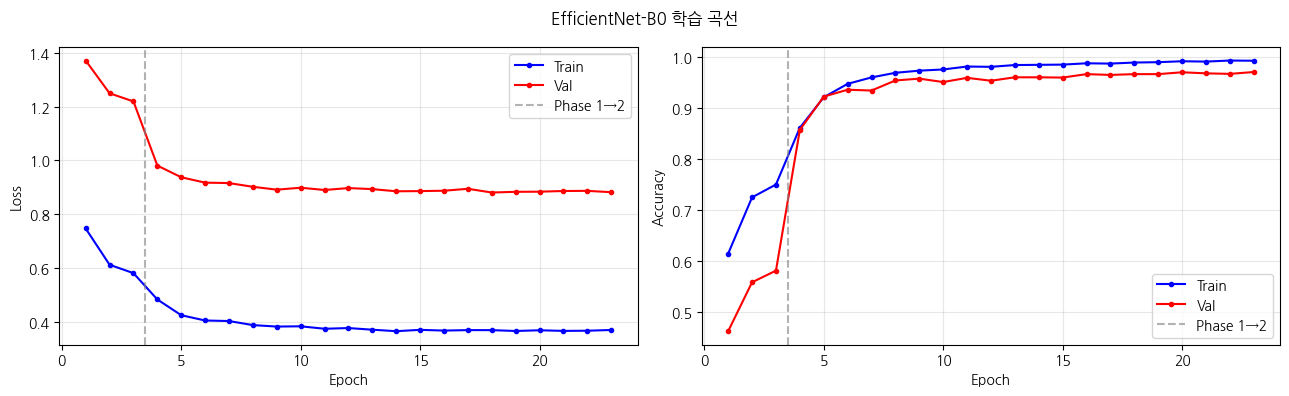

In [ ]:
# Phase 2
for p in effnet.parameters(): p.requires_grad = True
n_tr2 = sum(p.numel() for p in effnet.parameters() if p.requires_grad)
print(f'Phase 2 trainable: {n_tr2:,}')
print('='*60, '\n  Phase 2 — Full fine-tune  (lr=1e-4, up to 30 epochs)\n', '='*60)
effnet, hist_eff_p2 = train_model(
    effnet, train_loader, val_loader, epochs=30, lr=1e-4,
    name='eff_p2', class_weight_tensor=class_weights_t,
    patience=5,
)
hist_eff = merge_histories(hist_eff_p1, hist_eff_p2)
plot_curves(hist_eff, phase_split=len(hist_eff_p1['train_loss']),
            title='EfficientNet-B0 학습 곡선',
            save='curves_efficientnet.png')

In [ ]:
# ── EfficientNet Test 평가 ──
criterion_eval = nn.CrossEntropyLoss()
_, eff_acc, eff_preds, eff_labels, eff_probs = eval_epoch(effnet, test_loader, criterion_eval)
cm_eff = confusion_matrix(eff_labels, eff_preds)
eff_f1m  = f1_score(eff_labels, eff_preds, average='macro')
eff_f1w  = f1_score(eff_labels, eff_preds, average='weighted')
eff_prec = precision_score(eff_labels, eff_preds, average='macro', zero_division=0)
eff_rec  = recall_score(eff_labels, eff_preds, average='macro', zero_division=0)
eff_auc  = roc_auc_score(eff_labels, eff_probs, multi_class='ovr', average='macro')

print(f'[EfficientNet-B0 Test]')
print(f'  Accuracy : {eff_acc:.4f}')
print(f'  F1 macro/weighted : {eff_f1m:.4f} / {eff_f1w:.4f}')
print(f'  ROC-AUC (OvR)     : {eff_auc:.4f}')
print('\n--- 분류 리포트 ---')
print(classification_report(eff_labels, eff_preds, target_names=CLASS_LIST, zero_division=0))

[EfficientNet-B0 Test]
  Accuracy : 0.9675
  F1 macro/weighted : 0.9603 / 0.9677
  ROC-AUC (OvR)     : 0.9972

--- 분류 리포트 ---
                  precision    recall  f1-score   support

DangerousDriving       1.00      1.00      1.00       301
      Distracted       0.90      0.95      0.92       152
        Drinking       0.89      1.00      0.94        25
     SafeDriving       0.98      0.95      0.96       412
   SleepyDriving       0.94      0.96      0.95        69
            Yawn       0.96      1.00      0.98        26

        accuracy                           0.97       985
       macro avg       0.95      0.98      0.96       985
    weighted avg       0.97      0.97      0.97       985



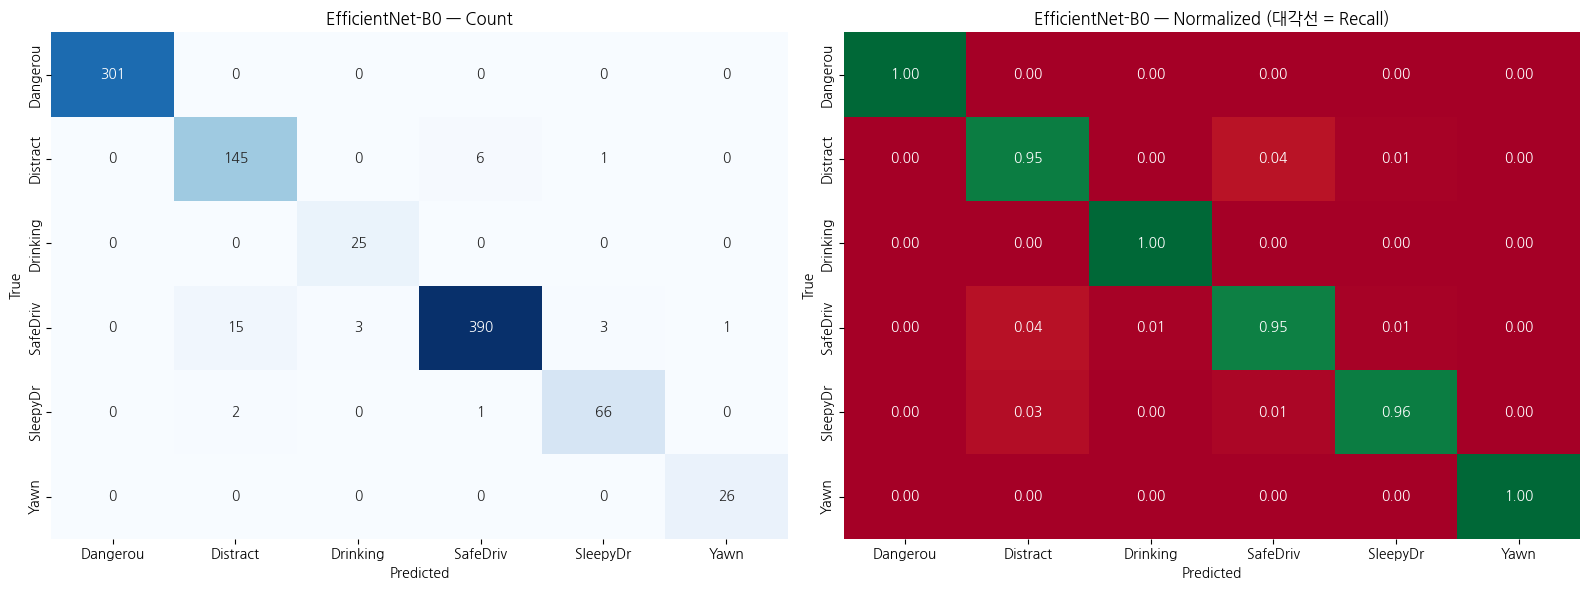

In [ ]:
def plot_cm(cm, title, save=None):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    short = [c[:8] for c in CLASS_LIST]
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=short, yticklabels=short, ax=axes[0], cbar=False)
    axes[0].set_title(f'{title} — Count', fontweight='bold')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn',
                xticklabels=short, yticklabels=short, ax=axes[1],
                vmin=0, vmax=1, cbar=False)
    axes[1].set_title(f'{title} — Normalized (대각선 = Recall)', fontweight='bold')
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
    plt.tight_layout()
    if save: plt.savefig(save, dpi=130, bbox_inches='tight')
    plt.show()

plot_cm(cm_eff, 'EfficientNet-B0', save='cm_efficientnet.png')

In [ ]:
# ── ② EfficientNet 저장 ──
import json
SAVE_DIR = '/content/drive/MyDrive/Machine_Learning_Term_Project/results'

torch.save(effnet.state_dict(), os.path.join(SAVE_DIR, 'effnet_b0_final.pth'))
np.savez(os.path.join(SAVE_DIR, '_eff_results.npz'),
         preds=eff_preds, probs=eff_probs, labels=eff_labels)
with open(os.path.join(SAVE_DIR, 'hist_eff.json'), 'w') as f:
    json.dump({'p1': hist_eff_p1, 'p2': hist_eff_p2}, f, indent=2)
print('EfficientNet-B0 저장 완료')

EfficientNet-B0 저장 완료


---
## 8. Model B — ViT-Small/patch16 (2-Phase)

Transformer 기반. CNN과 다른 attention 구조의 효과를 비교.

| Phase | 학습 대상 | LR | Epochs |
|-------|-----------|-----|--------|
| 1 | MLP head only | 1e-3 | 3 |
| 2 | 전체 fine-tune (ViT는 더 낮은 lr) | **5e-5** | 7 |

In [ ]:
def build_vit_small(num_classes, freeze=True):
    m = timm.create_model('vit_small_patch16_224', pretrained=True)
    if freeze:
        for p in m.parameters(): p.requires_grad = False
    in_f = m.head.in_features  # 384
    m.head = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_f, num_classes),
    )
    return m.to(device)

set_seed()
vit = build_vit_small(NUM_CLASSES, freeze=True)
n_tr = sum(p.numel() for p in vit.parameters() if p.requires_grad)
n_all = sum(p.numel() for p in vit.parameters())
print(f'ViT-Small — total: {n_all:,}, trainable: {n_tr:,} ({n_tr/n_all*100:.1f}%)')

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

ViT-Small — total: 21,667,974, trainable: 2,310 (0.0%)


In [ ]:
# Phase 1
print('='*60, '\n  Phase 1 — Head only  (lr=1e-3, 3 epochs warmup)\n', '='*60)
vit, hist_vit_p1 = train_model(
    vit, train_loader, val_loader, epochs=3, lr=1e-3,
    name='vit_p1', class_weight_tensor=class_weights_t,
    patience=99,
)

  Phase 1 — Head only  (lr=1e-3, 3 epochs warmup)
  Ep [01/3]  Tr L:0.8078 Acc:0.6081 | Vl L:1.6576 Acc:0.3881 | LR:7.50e-04  (132.1s) ✓ BEST
  Ep [02/3]  Tr L:0.6325 Acc:0.7212 | Vl L:1.3593 Acc:0.5068 | LR:2.51e-04  (122.8s) ✓ BEST
  Ep [03/3]  Tr L:0.6181 Acc:0.7330 | Vl L:1.3514 Acc:0.4969 | LR:1.00e-06  (122.2s) ✓ BEST

  best Val Loss: 1.3514


Phase 2 trainable: 21,667,974
  Phase 2 — Full fine-tune  (lr=5e-5, up to 30 epochs)
  Ep [01/30]  Tr L:0.3840 Acc:0.9721 | Vl L:0.9286 Acc:0.9303 | LR:4.99e-05  (169.0s) ✓ BEST
  Ep [02/30]  Tr L:0.3797 Acc:0.9765 | Vl L:0.8937 Acc:0.9532 | LR:4.95e-05  (153.1s) ✓ BEST
  Ep [03/30]  Tr L:0.3738 Acc:0.9782 | Vl L:0.8898 Acc:0.9547 | LR:4.88e-05  (152.4s) ✓ BEST
  Ep [04/30]  Tr L:0.3789 Acc:0.9779 | Vl L:0.9036 Acc:0.9480 | LR:4.79e-05  (147.3s) 
  Ep [05/30]  Tr L:0.3665 Acc:0.9842 | Vl L:0.8925 Acc:0.9553 | LR:4.67e-05  (150.9s) 
  Ep [06/30]  Tr L:0.3717 Acc:0.9822 | Vl L:0.9021 Acc:0.9589 | LR:4.53e-05  (148.9s) 
  Ep [07/30]  Tr L:0.3754 Acc:0.9820 | Vl L:0.8909 Acc:0.9625 | LR:4.37e-05  (148.8s) 
  Ep [08/30]  Tr L:0.3699 Acc:0.9850 | Vl L:0.8918 Acc:0.9636 | LR:4.19e-05  (150.1s) 
  Ep [09/30]  Tr L:0.3719 Acc:0.9857 | Vl L:0.9215 Acc:0.9376 | LR:3.99e-05  (152.2s) 
  Ep [10/30]  Tr L:0.3754 Acc:0.9854 | Vl L:0.8915 Acc:0.9579 | LR:3.78e-05  (156.6s) 
  Ep [11/30]  Tr L:0.3722 A

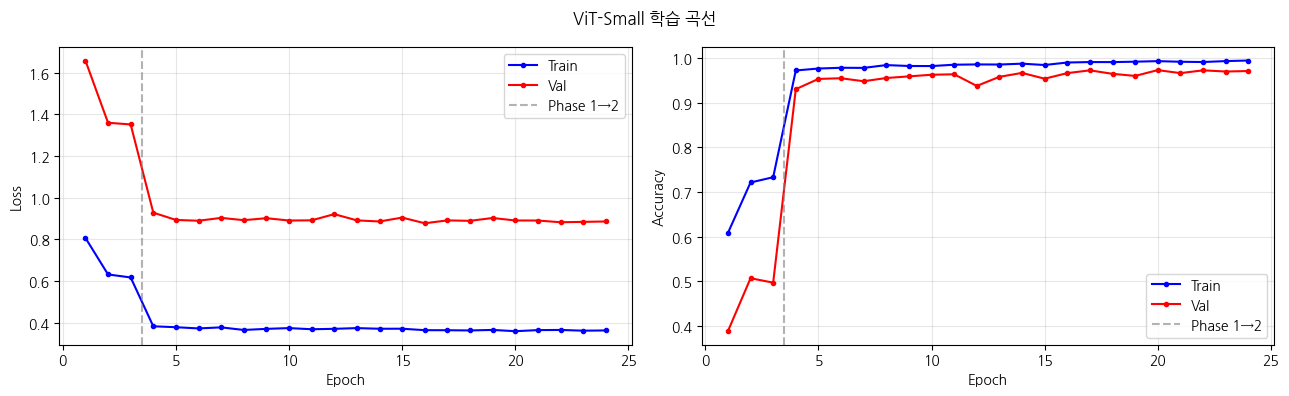

In [ ]:
# Phase 2
for p in vit.parameters(): p.requires_grad = True
n_tr2 = sum(p.numel() for p in vit.parameters() if p.requires_grad)
print(f'Phase 2 trainable: {n_tr2:,}')
print('='*60, '\n  Phase 2 — Full fine-tune  (lr=5e-5, up to 30 epochs)\n', '='*60)
vit, hist_vit_p2 = train_model(
    vit, train_loader, val_loader, epochs=30, lr=5e-5,
    name='vit_p2', class_weight_tensor=class_weights_t,
    patience=8,
)
hist_vit = merge_histories(hist_vit_p1, hist_vit_p2)
plot_curves(hist_vit, phase_split=len(hist_vit_p1['train_loss']),
            title='ViT-Small 학습 곡선',
            save='curves_vit.png')

[ViT-Small Test]
  Accuracy : 0.9756
  F1 macro/weighted : 0.9716 / 0.9757
  ROC-AUC (OvR)     : 0.9988

--- 분류 리포트 ---
                  precision    recall  f1-score   support

DangerousDriving       1.00      1.00      1.00       301
      Distracted       0.94      0.95      0.94       152
        Drinking       0.93      1.00      0.96        25
     SafeDriving       0.99      0.96      0.97       412
   SleepyDriving       0.92      0.99      0.95        69
            Yawn       1.00      1.00      1.00        26

        accuracy                           0.98       985
       macro avg       0.96      0.98      0.97       985
    weighted avg       0.98      0.98      0.98       985



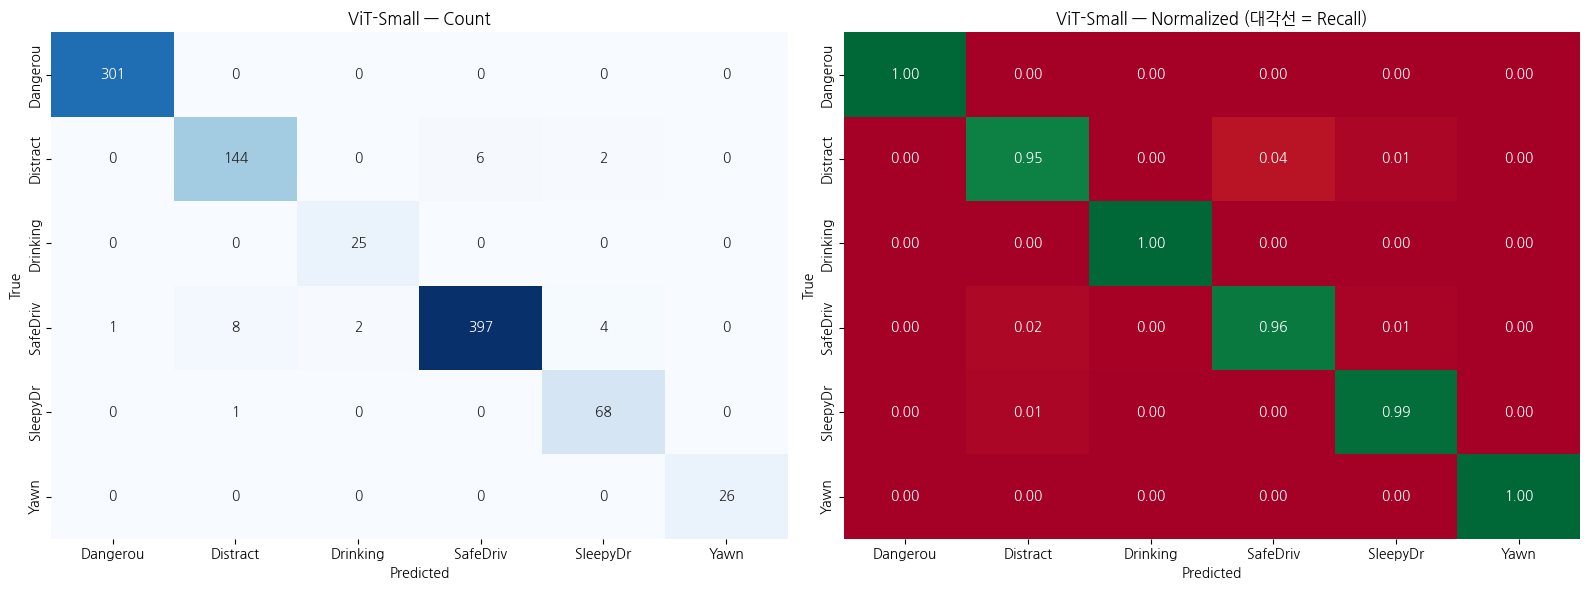

✓ ViT 저장


In [ ]:
# ── ViT Test 평가 ──
_, vit_acc, vit_preds, vit_labels, vit_probs = eval_epoch(vit, test_loader, criterion_eval)
cm_vit = confusion_matrix(vit_labels, vit_preds)
vit_f1m  = f1_score(vit_labels, vit_preds, average='macro')
vit_f1w  = f1_score(vit_labels, vit_preds, average='weighted')
vit_prec = precision_score(vit_labels, vit_preds, average='macro', zero_division=0)
vit_rec  = recall_score(vit_labels, vit_preds, average='macro', zero_division=0)
vit_auc  = roc_auc_score(vit_labels, vit_probs, multi_class='ovr', average='macro')

print(f'[ViT-Small Test]')
print(f'  Accuracy : {vit_acc:.4f}')
print(f'  F1 macro/weighted : {vit_f1m:.4f} / {vit_f1w:.4f}')
print(f'  ROC-AUC (OvR)     : {vit_auc:.4f}')
print('\n--- 분류 리포트 ---')
print(classification_report(vit_labels, vit_preds, target_names=CLASS_LIST, zero_division=0))

plot_cm(cm_vit, 'ViT-Small', save='cm_vit.png')

SAVE_DIR = '/content/drive/MyDrive/Machine_Learning_Term_Project/results'
os.makedirs(SAVE_DIR, exist_ok=True)
torch.save(vit.state_dict(), os.path.join(SAVE_DIR, 'vit_small_final.pth'))
np.savez(os.path.join(SAVE_DIR, '_tmp_vit.npz'),
         preds=vit_preds, probs=vit_probs, labels=vit_labels)
print('✓ ViT 저장')

In [ ]:
# ── 통합 test_results.npz 생성 (각 모델 결과 병합) ──
import numpy as np, os, json
SAVE_DIR = '/content/drive/MyDrive/Machine_Learning_Term_Project/results'

# ── SVM: 이전 세션에서 저장한 npz에서 로드 ──
svm_path = os.path.join(SAVE_DIR, '_svm_results.npz')
if os.path.exists(svm_path):
    d = np.load(svm_path)
    svm_preds, svm_probs, svm_labels = d['preds'], d['probs'], d['labels']
    print(f'✓ SVM npz 로드 ({len(svm_labels)}개)')
else:
    # _svm_results.npz가 없으면 다른 이름도 시도
    for alt in ['_tmp_svm.npz', 'svm_results.npz']:
        p = os.path.join(SAVE_DIR, alt)
        if os.path.exists(p):
            d = np.load(p)
            svm_preds, svm_probs, svm_labels = d['preds'], d['probs'], d['labels']
            print(f'✓ SVM 로드 (from {alt})')
            break
    else:
        raise FileNotFoundError('SVM 결과 npz를 못 찾았어요. Drive 확인 필요')

# ── EffNet: 메모리에 있으면 그대로, 없으면 npz 로드 ──
try:
    _ = eff_preds, eff_probs, eff_labels
    print('✓ EffNet 메모리에서 사용')
except NameError:
    d = np.load(os.path.join(SAVE_DIR, '_eff_results.npz'))
    eff_preds, eff_probs, eff_labels = d['preds'], d['probs'], d['labels']
    print('✓ EffNet npz 로드')

# ── ViT: 메모리에 있음 ──
try:
    _ = vit_preds, vit_probs, vit_labels
    print('✓ ViT 메모리에서 사용')
except NameError:
    d = np.load(os.path.join(SAVE_DIR, '_vit_results.npz'))
    vit_preds, vit_probs, vit_labels = d['preds'], d['probs'], d['labels']
    print('✓ ViT npz 로드')

# ── 통합 npz 저장 (분석 노트북이 읽는 형식) ──
np.savez(os.path.join(SAVE_DIR, 'test_results.npz'),
    labels_svm=svm_labels, labels_eff=eff_labels, labels_vit=vit_labels,
    preds_svm=svm_preds,   preds_eff=eff_preds,   preds_vit=vit_preds,
    probs_svm=svm_probs,   probs_eff=eff_probs,   probs_vit=vit_probs,
)

# ── ViT history 저장 (이 셀에서도 같이) ──
with open(os.path.join(SAVE_DIR, 'hist_vit.json'), 'w') as f:
    json.dump({'p1': hist_vit_p1, 'p2': hist_vit_p2}, f, indent=2)

print(f'\n✅ 통합 test_results.npz + hist_vit.json 저장 완료')
print('\n📁 Drive 파일 목록:')
for f in sorted(os.listdir(SAVE_DIR)):
    sz = os.path.getsize(os.path.join(SAVE_DIR, f))/1024
    print(f'  {f:<35} {sz:>8.1f} KB')

✓ SVM npz 로드 (985개)
✓ EffNet 메모리에서 사용
✓ ViT 메모리에서 사용

✅ 통합 test_results.npz + hist_vit.json 저장 완료

📁 Drive 파일 목록:
  _eff_results.npz                        39.2 KB
  _svm_results.npz                        62.3 KB
  _vit_results.npz                        39.2 KB
  df_test.parquet                         59.1 KB
  df_train.parquet                       654.3 KB
  effnet_b0_final.pth                  17236.5 KB
  hist_eff.json                            2.5 KB
  hist_vit.json                            2.7 KB
  hog_features.npz                    102477.7 KB
  hog_svm.joblib                         125.3 KB
  meta.json                                1.1 KB
  test_results.npz                       140.7 KB
  vit_small_final.pth                  84699.4 KB


---
## 9. 3-Model 비교

In [ ]:
# ── 결과 통합 ──
results = {
    'HOG+SVM (LinearSVC)': dict(
        preds=svm_preds, labels=y_test, probs=svm_probs,
        acc=svm_acc, f1_macro=svm_f1m, f1_weighted=svm_f1w, auc=svm_auc),
    'EfficientNet-B0': dict(
        preds=eff_preds, labels=eff_labels, probs=eff_probs,
        acc=eff_acc, f1_macro=eff_f1m, f1_weighted=eff_f1w, auc=eff_auc),
    'ViT-Small': dict(
        preds=vit_preds, labels=vit_labels, probs=vit_probs,
        acc=vit_acc, f1_macro=vit_f1m, f1_weighted=vit_f1w, auc=vit_auc),
}

cmp_df = pd.DataFrame({
    name: {
        'Accuracy':           r['acc'],
        'F1 (macro)':         r['f1_macro'],
        'F1 (weighted)':      r['f1_weighted'],
        'Precision (macro)':  precision_score(r['labels'], r['preds'], average='macro', zero_division=0),
        'Recall (macro)':     recall_score(r['labels'], r['preds'], average='macro', zero_division=0),
        'ROC-AUC (OvR)':      r['auc'],
    } for name, r in results.items()
}).T
print(cmp_df.to_string(float_format='{:.4f}'.format))
cmp_df.to_csv('comparison_table.csv', float_format='%.4f')

                     Accuracy  F1 (macro)  F1 (weighted)  Precision (macro)  Recall (macro)  ROC-AUC (OvR)
HOG+SVM (LinearSVC)    0.9117      0.8690         0.9122             0.8555          0.8858         0.9814
EfficientNet-B0        0.9675      0.9603         0.9677             0.9460          0.9762         0.9972
ViT-Small              0.9756      0.9716         0.9757             0.9613          0.9827         0.9988


---
## 10. 위험도 가중 평가 (Cost-sensitive Metric)

운전자 부주의 도메인에서 모든 오분류는 **동등하지 않다.**

- "SleepyDriving → SafeDriving" (실제 졸음인데 안전이라고 판단): **사고 직결** → 비용 ↑↑
- "SafeDriving → SleepyDriving" (안전인데 졸음 경보): false alarm → 비용 ↓
- 정답: 0
- 같은 위험도 그룹 내 혼동: 비용 보통

**비용 함수**: `cost(true=i, pred=j) = max(1, risk(i) − risk(j) + 1)²` (정답이면 0)

In [ ]:
# ── Cost matrix 정의 ──
cost_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES))
for i, ci in enumerate(CLASS_LIST):
    for j, cj in enumerate(CLASS_LIST):
        if i == j:
            cost_matrix[i, j] = 0
        else:
            ri = RISK_W[get_risk(ci)[0]]
            rj = RISK_W[get_risk(cj)[0]]
            cost_matrix[i, j] = max(1, ri - rj + 1) ** 2


def risk_weighted_score(y_true, y_pred):
    total_cost = float(sum(cost_matrix[t, p] for t, p in zip(y_true, y_pred)))
    max_cost   = cost_matrix.max() * len(y_true)
    return 1 - total_cost / max_cost, total_cost

print(f'{"Model":<22} {"Risk Score":>12} {"Total Cost":>12}')
print('-'*50)
risk_scores = {}
for name, r in results.items():
    rs, tc = risk_weighted_score(r['labels'], r['preds'])
    risk_scores[name] = rs
    print(f'{name:<22} {rs:>12.4f} {tc:>12.0f}')

Model                    Risk Score   Total Cost
--------------------------------------------------
HOG+SVM (LinearSVC)          0.9735          418
EfficientNet-B0              0.9936          101
ViT-Small                    0.9952           75


In [ ]:
# ── 클래스별 지표 + 위험도 그룹별 (best model) ──
best_name = cmp_df['F1 (macro)'].idxmax()
r = results[best_name]

per_prec = precision_score(r['labels'], r['preds'], average=None, zero_division=0)
per_rec  = recall_score(r['labels'], r['preds'], average=None, zero_division=0)
per_f1   = f1_score(r['labels'], r['preds'], average=None, zero_division=0)

per_df = pd.DataFrame({
    'class':     CLASS_LIST,
    'risk':      [get_risk(c)[0] for c in CLASS_LIST],
    'Precision': per_prec,
    'Recall':    per_rec,
    'F1':        per_f1,
    'Support':   [int((np.array(r['labels'])==i).sum()) for i in range(NUM_CLASSES)],
})
print(f'[Best 모델: {best_name}] 클래스별 지표')
print(per_df.to_string(index=False, float_format='{:.4f}'.format))
print(f'\n[위험도 그룹별 평균 — 사고 직결 지표]')
print(per_df.groupby('risk')[['Precision','Recall','F1']].mean().to_string(float_format='{:.4f}'.format))

[Best 모델: ViT-Small] 클래스별 지표
           class     risk  Precision  Recall     F1  Support
DangerousDriving Critical     0.9967  1.0000 0.9983      301
      Distracted     High     0.9412  0.9474 0.9443      152
        Drinking Critical     0.9259  1.0000 0.9615       25
     SafeDriving      Low     0.9851  0.9636 0.9742      412
   SleepyDriving Critical     0.9189  0.9855 0.9510       69
            Yawn   Medium     1.0000  1.0000 1.0000       26

[위험도 그룹별 평균 — 사고 직결 지표]
          Precision  Recall     F1
risk                              
Critical     0.9472  0.9952 0.9703
High         0.9412  0.9474 0.9443
Low          0.9851  0.9636 0.9742
Medium       1.0000  1.0000 1.0000


---
## 11. 최종 요약

In [ ]:
print('='*82)
print('         Driver Inattention Detection — 최종 결과')
print('='*82)
print(f'데이터셋: DMD (Roboflow) — Train {len(df_train)} / Val {len(df_val)} / Test {len(df_test)}')
print(f'클래스: {", ".join(CLASS_LIST)}')
print(f'전처리: bbox 크롭(+20% padding) → 224×224 → grayscale→3ch')
print(f'불균형 처리: WeightedRandomSampler + CE loss(weight=balanced)')
print('-'*82)
print(f'{"Model":<22} {"Acc":>8} {"F1_macro":>10} {"F1_w":>8} {"Prec_m":>8} {"Rec_m":>8} {"AUC":>8} {"Risk":>8}')
print('-'*82)
for name, r in results.items():
    prec_m = cmp_df.loc[name, 'Precision (macro)']
    rec_m  = cmp_df.loc[name, 'Recall (macro)']
    print(f'{name:<22} {r["acc"]:>8.4f} {r["f1_macro"]:>10.4f} {r["f1_weighted"]:>8.4f} '
          f'{prec_m:>8.4f} {rec_m:>8.4f} {r["auc"]:>8.4f} {risk_scores[name]:>8.4f}')
print('='*82)
print(f'\n→ 최고 F1 (macro) : {best_name}')
print(f'→ 최고 Risk Score : {max(risk_scores, key=risk_scores.get)}')

         Driver Inattention Detection — 최종 결과
데이터셋: DMD (Roboflow) — Train 11948 / Val 1922 / Test 985
클래스: DangerousDriving, Distracted, Drinking, SafeDriving, SleepyDriving, Yawn
전처리: bbox 크롭(+20% padding) → 224×224 → grayscale→3ch
불균형 처리: WeightedRandomSampler + CE loss(weight=balanced)
----------------------------------------------------------------------------------
Model                       Acc   F1_macro     F1_w   Prec_m    Rec_m      AUC     Risk
----------------------------------------------------------------------------------
HOG+SVM (LinearSVC)      0.9117     0.8690   0.9122   0.8555   0.8858   0.9814   0.9735
EfficientNet-B0          0.9675     0.9603   0.9677   0.9460   0.9762   0.9972   0.9936
ViT-Small                0.9756     0.9716   0.9757   0.9613   0.9827   0.9988   0.9952

→ 최고 F1 (macro) : ViT-Small
→ 최고 Risk Score : ViT-Small


---
## 12. 결과 저장 (Google Drive)

In [ ]:
# ── 결과 저장 (표 + 시각화 PNG만 — 모델/npz/meta/df는 ①②③에서 이미 저장됨) ──
SAVE_DIR = '/content/drive/MyDrive/Machine_Learning_Term_Project/results'

# (1) 표 (CSV)
cmp_df.to_csv(os.path.join(SAVE_DIR, 'comparison_table.csv'), float_format='%.4f')
per_df.to_csv(os.path.join(SAVE_DIR, 'per_class_metrics.csv'),
              index=False, float_format='%.4f')

# (2) 시각화 PNG 백업
for fname in ['eda_distribution.png', 'eda_samples.png',
              'eda_bbox_stats.png', 'eda_crops.png',
              'curves_efficientnet.png', 'curves_vit.png',
              'cm_efficientnet.png', 'cm_vit.png']:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(SAVE_DIR, fname))

print(f'✓ 표 + PNG 저장 완료\n')
print('전체 Drive 파일 목록:')
for f in sorted(os.listdir(SAVE_DIR)):
    sz = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1024
    print(f'  {f:<38} {sz:>9.1f} KB')

✓ 표 + PNG 저장 완료

전체 Drive 파일 목록:
  _eff_results.npz                            39.2 KB
  _svm_results.npz                            62.3 KB
  _vit_results.npz                            39.2 KB
  cm_efficientnet.png                         68.3 KB
  cm_vit.png                                  67.2 KB
  comparison_table.csv                         0.2 KB
  curves_efficientnet.png                     59.3 KB
  curves_vit.png                              58.9 KB
  df_test.parquet                             59.1 KB
  df_train.parquet                           654.3 KB
  eda_bbox_stats.png                         146.6 KB
  eda_crops.png                              314.7 KB
  eda_distribution.png                        87.8 KB
  eda_samples.png                            749.0 KB
  effnet_b0_final.pth                      17236.5 KB
  hist_eff.json                                2.5 KB
  hist_vit.json                                2.7 KB
  hog_features.npz                        102477.